In [ ]:
pip install scikit-fem matplotlib numpy torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 7.4 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick



plt.rcParams.update({
    "font.size": 14,        # 全部字體基準（ticks/labels/legend）
    "axes.titlesize": 16,   # title
    "axes.labelsize": 15,   # x/y label
    "xtick.labelsize": 13,  # x ticks
    "ytick.labelsize": 13,  # y ticks
    "legend.fontsize": 13,  # legend
})

Circular Domain Poisson Equation: DeepONet (only)
with Mesh Invariance Testing
📂 Loading existing dataset...
✓ Loaded 1000 samples

[2/6] Preparing data loaders...
Total samples : 1000
Train samples : 800
Val samples   : 100
Test samples  : 100
Batch size    : 16
Steps/epoch   : 50

[3/6] Training DeepONet on cuda...
DeepONet parameters: 187,009
[DeepONet] Epoch   1/100 | Train 1.687663e-04 | Val 1.537616e-04 | LR 1.00e-03
[DeepONet] Epoch  10/100 | Train 7.062913e-06 | Val 7.441451e-06 | LR 1.00e-03
[DeepONet] Epoch  20/100 | Train 4.505187e-06 | Val 4.821651e-06 | LR 1.00e-03
[DeepONet] Epoch  30/100 | Train 3.765901e-06 | Val 3.951693e-06 | LR 1.00e-03
[DeepONet] Epoch  40/100 | Train 5.310748e-06 | Val 5.545576e-06 | LR 1.00e-03
[DeepONet] Epoch  50/100 | Train 8.041285e-06 | Val 8.038126e-06 | LR 5.00e-04
[DeepONet] Epoch  60/100 | Train 2.412204e-06 | Val 2.634627e-06 | LR 5.00e-04
[DeepONet] Epoch  70/100 | Train 2.599680e-06 | Val 2.788317e-06 | LR 5.00e-04
[DeepONet] Epoch  80

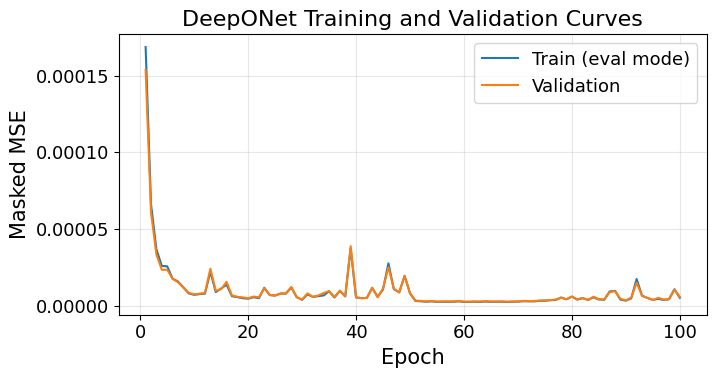

✓ Saved train/val curve to deeponet_train_val_curve.png
✓ Loaded best validation checkpoint.

[4/6] Evaluating on TEST set (same grid as training)...
✓ TEST MSE: 0.000003
✓ TEST Relative L2: 0.064670
✓ Saved to deeponet_test_metrics.txt

[5/6] Plotting example predictions...


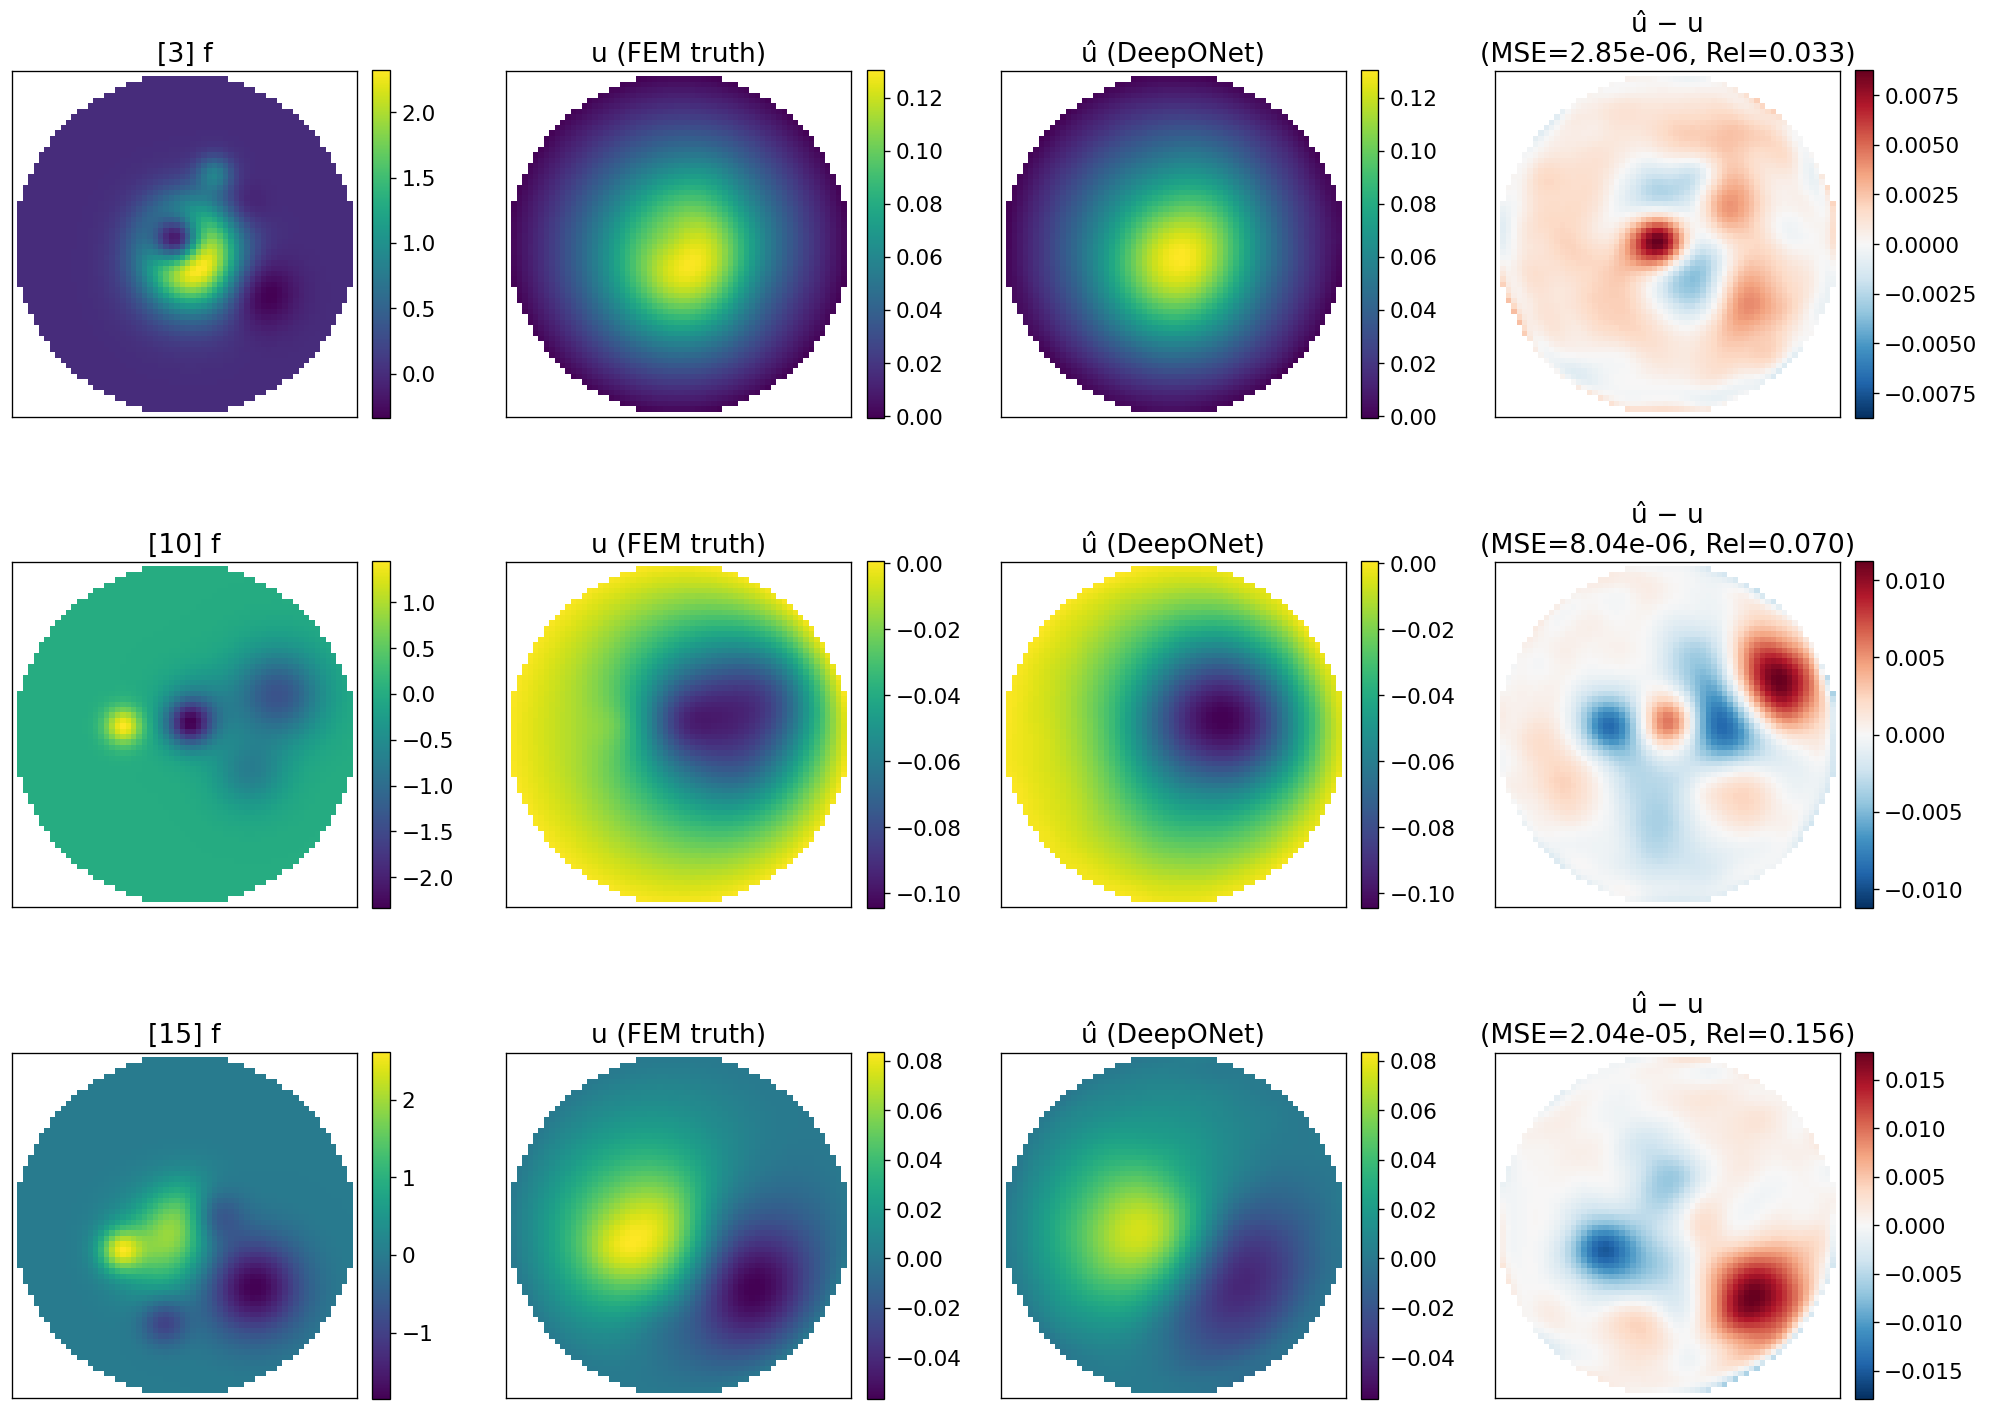

✓ Saved example panel to deeponet_examples.png

[6/6] Testing mesh invariance (DeepONet only)...

MESH INVARIANCE TEST (DeepONet only)
Training grid size: 64x64
Test grid sizes: [32, 48, 64, 80, 96, 128]

Testing on 32x32 grid...
  Generating data on 32x32 grid...
    Progress: 20/100
    Progress: 40/100
    Progress: 60/100
    Progress: 80/100
    Progress: 100/100
  DeepONet - MSE: 0.00000352, Rel Error: 0.06541139

Testing on 48x48 grid...
  Generating data on 48x48 grid...
    Progress: 20/100
    Progress: 40/100
    Progress: 60/100
    Progress: 80/100
    Progress: 100/100
  DeepONet - MSE: 0.00000344, Rel Error: 0.06492753

Testing on 64x64 grid...
  Generating data on 64x64 grid...
    Progress: 20/100
    Progress: 40/100
    Progress: 60/100
    Progress: 80/100
    Progress: 100/100
  DeepONet - MSE: 0.00000339, Rel Error: 0.06467018

Testing on 80x80 grid...
  Generating data on 80x80 grid...
    Progress: 20/100
    Progress: 40/100
    Progress: 60/100
    Progress: 8

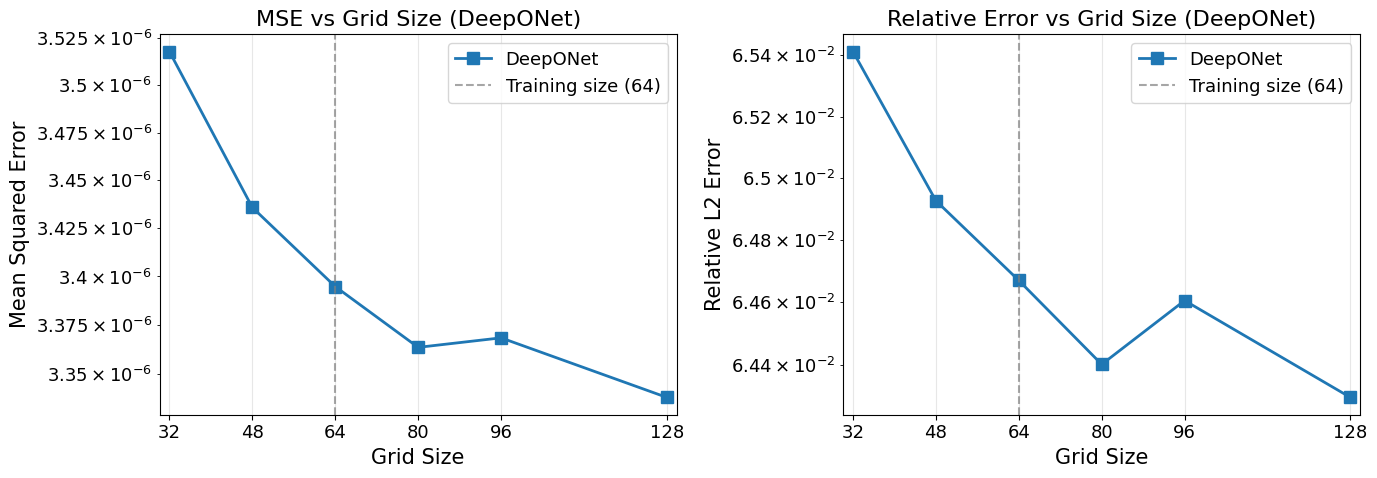


✓ Mesh invariance results saved to mesh_invariance_results_deeponet.png

MESH INVARIANCE SUMMARY (DeepONet)

Grid 32x32:
  DeepONet - MSE: 0.000004, Rel Error: 0.065411

Grid 48x48:
  DeepONet - MSE: 0.000003, Rel Error: 0.064928

Grid 64x64:
  DeepONet - MSE: 0.000003, Rel Error: 0.064670

Grid 80x80:
  DeepONet - MSE: 0.000003, Rel Error: 0.064401

Grid 96x96:
  DeepONet - MSE: 0.000003, Rel Error: 0.064606

Grid 128x128:
  DeepONet - MSE: 0.000003, Rel Error: 0.064295

✓ All done (DeepONet only)!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skfem import *
from skfem.helpers import *
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pickle
from scipy.interpolate import griddata
import torch.nn.functional as F
import random
import os
import math

# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# Data generation

class GaussianMixture2D:
    """Generate a 2D Gaussian mixture function."""
    def __init__(self, n_gaussians=5, radius=1.0):
        self.n_gaussians = n_gaussians
        self.radius = radius
        self.params = self._generate_params()

    def _generate_params(self):
        """Randomly generate Gaussian parameters inside the disk."""
        params = {
            'amplitudes': np.random.uniform(-2.0, 2.0, self.n_gaussians),
            'centers': [],
            'sigmas': np.random.uniform(0.05, 0.2, self.n_gaussians) * self.radius
        }
        for _ in range(self.n_gaussians):
            r = np.random.uniform(0, 0.6 * self.radius)
            theta = np.random.uniform(0, 2 * np.pi)
            x = r * np.cos(theta)
            y = r * np.sin(theta)
            params['centers'].append([x, y])
        params['centers'] = np.array(params['centers'])
        return params

    def evaluate(self, x, y):
        """Evaluate f at the given coordinates."""
        result = np.zeros_like(x)
        for i in range(self.n_gaussians):
            a_i = self.params['amplitudes'][i]
            c_i = self.params['centers'][i]
            sigma_i = self.params['sigmas'][i]
            dist_sq = (x - c_i[0])**2 + (y - c_i[1])**2
            result += a_i * np.exp(-dist_sq / (2 * sigma_i**2))
        return result


class CircularPoissonFEMSolver:
    """FEM solver for the Poisson equation on a circular domain."""
    def __init__(self, radius=1.0, n_refine=6):
        self.radius = radius
        m = MeshTri.init_circle(nrefs=n_refine)
        self.mesh = MeshTri(m.p * radius, m.t)
        self.basis = Basis(self.mesh, ElementTriP1())

    def solve(self, f_func):
        """Solve the Poisson equation on a circular domain with zero boundary condition."""
        @BilinearForm
        def laplacian(u, v, _):
            return dot(grad(u), grad(v))

        @LinearForm
        def rhs(v, w):
            x, y = w.x
            f_values = f_func(x, y)
            return f_values * v

        K = laplacian.assemble(self.basis)
        f = rhs.assemble(self.basis)

        try:
            D = self.basis.get_dofs(self.mesh.boundary_facets())
        except Exception:
            D = self.basis.get_dofs()

        u_fem = solve(*condense(K, f, D=D))
        return u_fem

    def interpolate_to_grid(self, u_fem, nx=64, ny=64):
        """Interpolate the FEM solution to a regular grid; use nearest interpolation to fill holes from linear interpolation and set values outside the disk to zero."""
        x = np.linspace(-self.radius, self.radius, nx)
        y = np.linspace(-self.radius, self.radius, ny)
        X, Y = np.meshgrid(x, y)

        fem_points = self.mesh.p.T
        pts_grid = np.column_stack([X.ravel(), Y.ravel()])

        u_lin = griddata(fem_points, np.asarray(u_fem), pts_grid, method='linear')
        u_lin = u_lin.reshape(ny, nx)

        if np.isnan(u_lin).any():
            u_nn = griddata(fem_points, np.asarray(u_fem), pts_grid, method='nearest')
            u_nn = u_nn.reshape(ny, nx)
            nan_mask = np.isnan(u_lin)
            u_lin[nan_mask] = u_nn[nan_mask]

        outside = (X**2 + Y**2) > (self.radius**2)
        u_lin[outside] = 0.0

        return u_lin.astype(np.float32), X, Y


class CircularDatasetGenerator:
    """Generate a dataset on a circular domain."""
    def __init__(self, n_samples=1000, radius=1.0, nx=64, ny=64, n_gaussians_range=(3, 8)):
        self.n_samples = n_samples
        self.radius = radius
        self.nx = nx
        self.ny = ny
        self.n_gaussians_range = n_gaussians_range
        self.solver = CircularPoissonFEMSolver(radius=radius, n_refine=6)

    def generate_dataset(self):
        dataset = {'f': [], 'u': [], 'params': [], 'mask': None}
        print(f"Generating {self.n_samples} samples on circular domain...")

        x = np.linspace(-self.radius, self.radius, self.nx)
        y = np.linspace(-self.radius, self.radius, self.ny)
        X, Y = np.meshgrid(x, y)
        mask = X**2 + Y**2 <= self.radius**2
        dataset['mask'] = mask.astype(np.float32)

        for i in range(self.n_samples):
            if (i + 1) % 100 == 0:
                print(f"  Progress: {i+1}/{self.n_samples}")

            n_gaussians = np.random.randint(*self.n_gaussians_range)
            gm = GaussianMixture2D(n_gaussians=n_gaussians, radius=self.radius)

            def f_func(xq, yq):
                return gm.evaluate(xq, yq)

            u_fem = self.solver.solve(f_func)
            u_grid, X, Y = self.solver.interpolate_to_grid(u_fem, self.nx, self.ny)

            f_grid = gm.evaluate(X, Y).astype(np.float32)
            f_grid[~mask] = 0.0

            dataset['f'].append(f_grid)
            dataset['u'].append(u_grid)
            dataset['params'].append(gm.params)

        dataset['f'] = np.array(dataset['f'], dtype=np.float32)
        dataset['u'] = np.array(dataset['u'], dtype=np.float32)

        print("Dataset generation complete!")
        return dataset

    def save_dataset(self, dataset, filename='circular_poisson_dataset.npz'):
        np.savez_compressed(filename, f=dataset['f'], u=dataset['u'], mask=dataset['mask'])
        with open(filename.replace('.npz', '_params.pkl'), 'wb') as file:
            pickle.dump(dataset['params'], file)
        print(f"Dataset saved to {filename}")


# Fourier features

class FourierFeatures(nn.Module):
    """
    Map coordinates x in R^{in_dim} to a high-frequency feature space:
      - kind 'gauss': random Fourier features with B sampled from a normal distribution.
      - kind 'log2': NeRF-style frequency bands using powers of two times the scale factor.
    """
    def __init__(self, in_dim: int, n_ff: int = 64, kind: str = 'gauss',
                 sigma: float = 3.0, scale: float = math.pi, include_input: bool = True):
        super().__init__()
        self.in_dim = in_dim
        self.n_ff = n_ff
        self.kind = kind
        self.sigma = sigma
        self.scale = scale
        self.include_input = include_input

        if kind == 'gauss':
            B = torch.randn(in_dim, n_ff) * sigma
            self.register_buffer('B', B)
        elif kind == 'log2':
            freqs = (2.0 ** torch.arange(n_ff)) * scale
            self.register_buffer('freqs', freqs)
        else:
            raise ValueError("kind 必須是 {'gauss', 'log2'} 之一")

    @property
    def out_dim(self) -> int:
        base = self.in_dim if self.include_input else 0
        if self.kind == 'gauss':
            return base + 2 * self.n_ff
        else:
            return base + 2 * self.n_ff * self.in_dim

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.kind == 'gauss':
            proj = x @ self.B
            s = torch.sin(proj)
            c = torch.cos(proj)
            enc = torch.cat([s, c], dim=-1)
        else:
            parts = []
            for d in range(self.in_dim):
                xd = x[..., d:d+1] * self.freqs
                parts.append(torch.sin(xd))
                parts.append(torch.cos(xd))
            enc = torch.cat(parts, dim=-1)

        if self.include_input:
            return torch.cat([x, enc], dim=-1)
        return enc


# PyTorch Dataset

class PoissonDataset(Dataset):
    def __init__(self, f, u, mask):
        self.f = torch.from_numpy(f).float()
        self.u = torch.from_numpy(u).float()
        self.mask = torch.from_numpy(mask).float()  # (H, W)

    def __len__(self):
        return len(self.f)

    def __getitem__(self, idx):
        return self.f[idx], self.u[idx], self.mask


# Basis projector

class BasisProjector2D(nn.Module):
    """
    Project f(x, y) onto a 2D DCT-type basis using weighted inner products.
    """
    def __init__(self, radius=1.0, Lx=12, Ly=12, include_const=True, cache=True):
        super().__init__()
        self.radius = float(radius)
        self.Lx = int(Lx)
        self.Ly = int(Ly)
        self.include_const = bool(include_const)
        self.cache = {} if cache else None

        kxs = list(range(self.Lx + 1))
        kys = list(range(self.Ly + 1))
        if not include_const:
            pairs = [(kx, ky) for kx in kxs for ky in kys if not (kx == 0 and ky == 0)]
        else:
            pairs = [(kx, ky) for kx in kxs for ky in kys]
        self.k_pairs = pairs

    @property
    def num_basis(self):
        return len(self.k_pairs)

    def _build_cache(self, H, W, device):
        R = self.radius
        xv = torch.linspace(-R, R, W, device=device)
        yv = torch.linspace(-R, R, H, device=device)
        Y, X = torch.meshgrid(yv, xv, indexing='ij')
        mask = (X**2 + Y**2) <= (R * R)

        dx = (2.0 * R) / float(W)
        dy = (2.0 * R) / float(H)
        w = (dx * dy) * mask

        u = (X + R) / (2.0 * R)
        v = (Y + R) / (2.0 * R)

        N = H * W
        K = self.num_basis
        Phi = torch.empty(N, K, device=device)

        col = 0
        for (kx, ky) in self.k_pairs:
            phi = torch.cos(math.pi * kx * u) * torch.cos(math.pi * ky * v)
            phi = phi * mask
            Phi[:, col] = phi.reshape(-1)
            col += 1

        w_flat = w.reshape(-1, 1)
        norm = torch.sqrt(torch.clamp((w_flat * (Phi**2)).sum(dim=0, keepdim=True), min=1e-12))
        Phi = Phi / norm

        if self.cache is not None:
            self.cache[(H, W, device)] = (Phi, w.reshape(-1))
        return Phi, w.reshape(-1)

    def _get_cached(self, H, W, device):
        if self.cache is not None and (H, W, device) in self.cache:
            return self.cache[(H, W, device)]
        return self._build_cache(H, W, device)

    def project(self, f: torch.Tensor):
        """
        f: (B, H, W)
        Return c: (B, K)
        """
        assert f.dim() == 3, "f 需為 (B,H,W)"
        B, H, W = f.shape
        device = f.device
        Phi, w = self._get_cached(H, W, device)
        f_flat = f.reshape(B, -1)
        fw = f_flat * w.unsqueeze(0)
        c = fw @ Phi
        return c


# DeepONet

class DeepONet(nn.Module):
    def __init__(self,
                 branch_layers=[64*64, 128, 128, 128],
                 trunk_layers=[2, 128, 128, 128],
                 p=128,
                 use_fourier_trunk=True,
                 ff_kind='gauss',
                 ff_n=64,
                 ff_sigma=3.0,
                 ff_scale=math.pi,
                 ff_include_input=True,
                 projector=None):
        super().__init__()
        self.p = p
        self.projector = projector

        if self.projector is not None:
            in_dim_branch = self.projector.num_basis
        else:
            in_dim_branch = branch_layers[0]

        branch_dims = [in_dim_branch] + branch_layers[1:]
        branch = []
        for i in range(len(branch_dims) - 1):
            branch.append(nn.Linear(branch_dims[i], branch_dims[i+1]))
            branch.append(nn.ReLU())
        branch.append(nn.Linear(branch_dims[-1], p))
        self.branch = nn.Sequential(*branch)

        assert len(trunk_layers) >= 2 and trunk_layers[0] == 2, "trunk_layers[0] 應為 2（x,y）"
        trunk_hidden = trunk_layers[1:]

        self.trunk_ff = None
        trunk_in_dim = trunk_layers[0]
        if use_fourier_trunk:
            self.trunk_ff = FourierFeatures(
                in_dim=trunk_layers[0],
                n_ff=ff_n,
                kind=ff_kind,
                sigma=ff_sigma,
                scale=ff_scale,
                include_input=ff_include_input
            )
            trunk_in_dim = self.trunk_ff.out_dim

        trunk = []
        prev = trunk_in_dim
        for h in trunk_hidden:
            trunk += [nn.Linear(prev, h), nn.Tanh()]
            prev = h
        trunk += [nn.Linear(prev, p)]
        self.trunk = nn.Sequential(*trunk)

        self.b = nn.Parameter(torch.zeros(1))
        self._legacy_flatten_size = branch_layers[0]

    def forward(self, f, coords):
        """
        f: (B, H, W)
        coords: (N,2) or (B,N,2)
        """
        B, H, W = f.shape

        if self.projector is not None:
            c = self.projector.project(f)
        else:
            f_flat = f.reshape(B, -1)
            if f_flat.shape[1] != self._legacy_flatten_size:
                original_size = int(np.sqrt(f_flat.shape[1]))
                target_size = int(np.sqrt(self._legacy_flatten_size))
                f_reshaped = f_flat.reshape(B, 1, original_size, original_size)
                f_resized = F.interpolate(
                    f_reshaped, size=(target_size, target_size),
                    mode='bilinear', align_corners=False
                )
                f_flat = f_resized.reshape(B, -1)
            c = f_flat

        branch_out = self.branch(c)

        if coords.dim() == 2:
            coords = coords.unsqueeze(0).expand(B, -1, -1)

        if self.trunk_ff is not None:
            coords = self.trunk_ff(coords)

        trunk_out = self.trunk(coords)
        out = torch.einsum('bp,bnp->bn', branch_out, trunk_out) + self.b
        return out


# Metrics and utilities

def masked_mse(pred, target, mask):
    if mask.dim() == 2:
        mask = mask.unsqueeze(0).expand_as(pred)
    num = ((pred - target) ** 2 * mask).sum()
    den = mask.sum().clamp_min(1.0)
    return num / den


def masked_rel_l2(pred, target, mask):
    if mask.dim() == 2:
        mask = mask.unsqueeze(0).expand_as(pred)
    num = (((pred - target) ** 2) * mask).sum().sqrt()
    den = ((target ** 2) * mask).sum().sqrt().clamp_min(1e-12)
    return num / den


def make_coords(grid_size, radius, device):
    xv = torch.linspace(-radius, radius, grid_size, device=device)
    yv = torch.linspace(-radius, radius, grid_size, device=device)
    Yg, Xg = torch.meshgrid(yv, xv, indexing='ij')
    return torch.stack([Xg.flatten(), Yg.flatten()], dim=1)


def count_params(model: nn.Module):
    return sum(p.numel() for p in model.parameters())


# Epoch-end evaluation

def evaluate_epoch_mse_deeponet(model, data_loader, grid_size, radius=1.0, device='cuda'):
    """
    Compute the aggregated masked MSE over the whole data_loader.
    This is used for the train / validation curve and is aligned with the FNO protocol.
    """
    model.eval()
    coords = make_coords(grid_size, radius, device)

    err2_sum = 0.0
    pix_sum = 0.0

    with torch.no_grad():
        for f, u, mask in data_loader:
            f = f.to(device)
            u = u.to(device)
            mask = mask.to(device)

            pred = model(f, coords).reshape(f.size(0), grid_size, grid_size)

            if mask.dim() == 2:
                mask_b = mask.unsqueeze(0).expand_as(pred)
            else:
                mask_b = mask

            err2_sum += torch.sum(((pred - u) ** 2) * mask_b).item()
            pix_sum += torch.sum(mask_b).item()

    return err2_sum / max(pix_sum, 1.0)


def evaluate_loader_deeponet(model: nn.Module, data_loader, grid_size, radius=1.0, device='cuda'):
    """
    Compute the aggregated masked MSE and masked relative L2 over the whole data_loader.
    """
    model.eval()
    coords = make_coords(grid_size, radius, device)
    err2_sum = 0.0
    tgt2_sum = 0.0
    pix_sum = 0.0

    with torch.no_grad():
        for f, u, mask in data_loader:
            f = f.to(device)
            u = u.to(device)
            mask = mask.to(device)

            if mask.dim() == 2:
                mask_b = mask.unsqueeze(0).expand(f.size(0), -1, -1)
            else:
                mask_b = mask

            pred = model(f, coords).reshape(f.size(0), grid_size, grid_size)

            diff = (pred - u) * mask_b
            err2_sum += torch.sum(diff ** 2).item()
            tgt2_sum += torch.sum((u * mask_b) ** 2).item()
            pix_sum += torch.sum(mask_b).item()

    mse = err2_sum / max(pix_sum, 1.0)
    rel_l2 = (err2_sum ** 0.5) / (max(tgt2_sum, 1e-12) ** 0.5)
    return mse, rel_l2


# Training

def train_deeponet(model, train_loader, val_loader, train_eval_loader=None,
                   epochs=100, lr=1e-3, device='cuda', grid_size=64, radius=1.0,
                   save_best_path='best_deeponet.pt'):
    """
    DeepONet training procedure aligned with the FNO protocol:
    - Use the normal backward and update steps during training.
    - Recompute train and validation losses in eval mode after each epoch.
    - Save the best validation model.
    """
    if train_eval_loader is None:
        train_eval_loader = train_loader

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-6)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

    train_losses = []
    val_losses = []
    best_val = float('inf')

    coords = make_coords(grid_size, radius, device)

    for epoch in range(epochs):
        model.train()

        # ---------- training phase ----------
        for f, u, mask in train_loader:
            f = f.to(device)
            u = u.to(device)
            mask = mask.to(device)

            optimizer.zero_grad()
            pred = model(f, coords).reshape(f.size(0), grid_size, grid_size)
            loss = masked_mse(pred, u, mask)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        # ---------- evaluation phase ----------
        train_loss = evaluate_epoch_mse_deeponet(
            model, train_eval_loader, grid_size=grid_size, radius=radius, device=device
        )
        val_loss = evaluate_epoch_mse_deeponet(
            model, val_loader, grid_size=grid_size, radius=radius, device=device
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), save_best_path)

        scheduler.step()

        if (epoch + 1) % 10 == 0 or epoch == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"[DeepONet] Epoch {epoch+1:3d}/{epochs} | "
                  f"Train {train_loss:.6e} | "
                  f"Val {val_loss:.6e} | "
                  f"LR {current_lr:.2e}")

    print(f"✓ Best validation model saved to {save_best_path} (best val = {best_val:.6e})")
    return train_losses, val_losses


# Training curve plot

def plot_train_val(train_losses, val_losses, out='deeponet_train_val_curve.png'):
    plt.figure(figsize=(7.5, 4))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train (eval mode)')
    plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel('Masked MSE')
    plt.title('DeepONet Training and Validation Curves')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved train/val curve to {out}")


# Mesh invariance test data

def generate_test_data_different_mesh(params_list, grid_size, radius=1.0):
    solver = CircularPoissonFEMSolver(radius=radius, n_refine=6)
    x = np.linspace(-radius, radius, grid_size)
    y = np.linspace(-radius, radius, grid_size)
    X, Y = np.meshgrid(x, y)
    mask = (X**2 + Y**2) <= radius**2

    f_list, u_list = [], []
    print(f"  Generating data on {grid_size}x{grid_size} grid...")
    for i, params in enumerate(params_list):
        if (i + 1) % 20 == 0:
            print(f"    Progress: {i+1}/{len(params_list)}")

        gm = GaussianMixture2D(n_gaussians=len(params['amplitudes']), radius=radius)
        gm.params = params

        def f_func(xq, yq):
            return gm.evaluate(xq, yq)

        u_fem = solver.solve(f_func)
        u_grid, _, _ = solver.interpolate_to_grid(u_fem, grid_size, grid_size)
        np.nan_to_num(u_grid, copy=False, nan=0.0, posinf=0.0, neginf=0.0)

        f_grid = gm.evaluate(X, Y).astype(np.float32)
        f_grid[~mask] = 0.0

        f_list.append(f_grid.astype(np.float32))
        u_list.append(u_grid.astype(np.float32))

    return np.array(f_list), np.array(u_list), mask.astype(np.float32)


# Mesh invariance test for DeepONet

def test_mesh_invariance_deeponet(deeponet_model, test_params,
                                  test_grid_sizes=[32, 48, 64, 80, 96, 128],
                                  train_grid_size=64, device='cuda', radius=1.0):
    print("\n" + "="*60)
    print("MESH INVARIANCE TEST (DeepONet only)")
    print("="*60)
    print(f"Training grid size: {train_grid_size}x{train_grid_size}")
    print(f"Test grid sizes: {test_grid_sizes}")

    deeponet_model.eval()
    results = {'grid_sizes': test_grid_sizes, 'deeponet': {'mse': [], 'rel_error': []}}

    for grid_size in test_grid_sizes:
        print(f"\nTesting on {grid_size}x{grid_size} grid...")
        f_test, u_test, mask = generate_test_data_different_mesh(test_params, grid_size, radius=radius)
        f_tensor = torch.from_numpy(f_test).to(device)
        u_tensor = torch.from_numpy(u_test).to(device)
        mask_tensor = torch.from_numpy(mask).to(device)
        coords = make_coords(grid_size, radius, device)

        with torch.no_grad():
            don_pred = deeponet_model(f_tensor, coords).reshape(len(f_test), grid_size, grid_size)
            don_mse = masked_mse(don_pred, u_tensor, mask_tensor).item()
            don_rel = masked_rel_l2(don_pred, u_tensor, mask_tensor).item()

        results['deeponet']['mse'].append(don_mse)
        results['deeponet']['rel_error'].append(don_rel)
        print(f"  DeepONet - MSE: {don_mse:.8f}, Rel Error: {don_rel:.8f}")

    return results


def plot_mesh_invariance_results_deeponet(results, train_grid_size=64):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    grid_sizes = results['grid_sizes']
    xticks = sorted(set(list(grid_sizes) + [train_grid_size]))

    for ax in axes:
        ax.set_xticks(xticks)
        ax.set_xticklabels([str(int(x)) for x in xticks])
        ax.margins(x=0.02)

    axes[0].plot(grid_sizes, results['deeponet']['mse'], 's-', label='DeepONet', linewidth=2, markersize=8)
    axes[0].axvline(train_grid_size, color='gray', linestyle='--', alpha=0.7,
                    label=f'Training size ({train_grid_size})')
    axes[0].set_xlabel('Grid Size')
    axes[0].set_ylabel('Mean Squared Error')
    axes[0].set_title('MSE vs Grid Size (DeepONet)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_yscale('log')

    axes[1].plot(grid_sizes, results['deeponet']['rel_error'], 's-', label='DeepONet', linewidth=2, markersize=8)
    axes[1].axvline(train_grid_size, color='gray', linestyle='--', alpha=0.7,
                    label=f'Training size ({train_grid_size})')
    axes[1].set_xlabel('Grid Size')
    axes[1].set_ylabel('Relative L2 Error')
    axes[1].set_title('Relative Error vs Grid Size (DeepONet)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_yscale('log')

    plt.tight_layout()
    plt.savefig('mesh_invariance_results_deeponet.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✓ Mesh invariance results saved to mesh_invariance_results_deeponet.png")


# Visualization: f, true solution, prediction, and difference

def plot_examples_deeponet(model: nn.Module, dataset: Dataset, device='cuda',
                           idxs=None, n_show=3, radius=1.0,
                           cmap_f='viridis', cmap_u='viridis', cmap_diff='RdBu_r',
                           out_path='deeponet_examples.png'):
    """
    Plot four columns for each sample: f, true solution, prediction, and difference.
    The true solution and prediction share the same color scale.
    """
    model.eval()
    N = len(dataset)
    if idxs is None:
        if n_show >= N:
            idxs = list(range(N))
        else:
            idxs = np.linspace(0, N - 1, n_show, dtype=int).tolist()
    else:
        idxs = sorted(set([i for i in idxs if 0 <= i < N]))
        if len(idxs) == 0:
            raise ValueError("idxs 皆越界，請提供有效索引")

    rows = len(idxs)
    cols = 4
    plt.figure(figsize=(4.2 * cols, 4.2 * rows), dpi=120)

    with torch.no_grad():
        for r, i in enumerate(idxs):
            f, u, mask = dataset[i]
            H, W = f.shape[-2], f.shape[-1]
            f_np = f.numpy()
            u_np = u.numpy()
            mask_b = mask.numpy() > 0.5

            coords = make_coords(H, radius, device)
            f_in = f.unsqueeze(0).to(device)
            pred = model(f_in, coords).reshape(1, H, W).squeeze(0).detach().cpu().numpy()

            u_inside = np.where(mask_b, u_np, np.nan)
            pred_inside = np.where(mask_b, pred, np.nan)

            umin = np.nanmin([np.nanmin(u_inside), np.nanmin(pred_inside)])
            umax = np.nanmax([np.nanmax(u_inside), np.nanmax(pred_inside)])
            if not np.isfinite(umin) or not np.isfinite(umax) or umin == umax:
                umin, umax = -1.0, 1.0

            diff = np.where(mask_b, pred - u_np, np.nan)
            ad = np.nanmax(np.abs(diff))
            dlim = 1e-12 if (not np.isfinite(ad) or ad == 0.0) else ad

            ax = plt.subplot(rows, cols, r * cols + 1)
            im = ax.imshow(np.ma.masked_where(~mask_b, f_np), origin='lower',
                           interpolation='nearest', cmap=cmap_f)
            ax.set_title(f"[{i}] f")
            ax.set_xticks([])
            ax.set_yticks([])
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

            ax = plt.subplot(rows, cols, r * cols + 2)
            im = ax.imshow(np.ma.masked_where(~mask_b, u_np), origin='lower',
                           interpolation='nearest', cmap=cmap_u, vmin=umin, vmax=umax)
            ax.set_title("u (FEM truth)")
            ax.set_xticks([])
            ax.set_yticks([])
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

            ax = plt.subplot(rows, cols, r * cols + 3)
            im = ax.imshow(np.ma.masked_where(~mask_b, pred), origin='lower',
                           interpolation='nearest', cmap=cmap_u, vmin=umin, vmax=umax)
            ax.set_title("û (DeepONet)")
            ax.set_xticks([])
            ax.set_yticks([])
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

            ax = plt.subplot(rows, cols, r * cols + 4)
            im = ax.imshow(np.ma.masked_where(~mask_b, diff), origin='lower',
                           interpolation='nearest', vmin=-dlim, vmax=dlim, cmap=cmap_diff)
            mse_val = np.nanmean(((pred - u_np) ** 2)[mask_b])
            rel_val = (np.sqrt(np.nansum(((pred - u_np) ** 2)[mask_b])) /
                       max(np.sqrt(np.nansum((u_np ** 2)[mask_b])), 1e-12))
            ax.set_title(f"û − u\n(MSE={mse_val:.2e}, Rel={rel_val:.3f})")
            ax.set_xticks([])
            ax.set_yticks([])
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.savefig(out_path, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved example panel to {out_path}")


# Main program

if __name__ == "__main__":
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    N_SAMPLES = 1000
    GRID_SIZE = 64
    BATCH_SIZE = 16
    EPOCHS = 100
    RADIUS = 1.0

    TEST_GRID_SIZES = [32, 48, 64, 80, 96, 128]
    N_MESH_TEST_SAMPLES = 100

    print("=" * 60)
    print("Circular Domain Poisson Equation: DeepONet (only)")
    print("with Mesh Invariance Testing")
    print("=" * 60)

    # Load or generate data
    dataset_file = 'circular_poisson_dataset.npz'
    params_file = dataset_file.replace('.npz', '_params.pkl')

    if os.path.exists(dataset_file) and os.path.exists(params_file):
        print("📂 Loading existing dataset...")
        data = np.load(dataset_file)
        dataset = {'f': data['f'], 'u': data['u'], 'mask': data['mask']}
        with open(params_file, 'rb') as file:
            dataset['params'] = pickle.load(file)
        print(f"✓ Loaded {len(dataset['f'])} samples")
    else:
        print("🔄 Generating new dataset...")
        generator = CircularDatasetGenerator(
            n_samples=N_SAMPLES, nx=GRID_SIZE, ny=GRID_SIZE, radius=RADIUS
        )
        dataset = generator.generate_dataset()
        generator.save_dataset(dataset, filename=dataset_file)

    # DataLoaders
    print("\n[2/6] Preparing data loaders...")
    N_TOTAL = len(dataset['f'])
    n_train = int(0.8 * N_TOTAL)
    n_val = int(0.1 * N_TOTAL)

    train_dataset = PoissonDataset(
        dataset['f'][:n_train],
        dataset['u'][:n_train],
        dataset['mask']
    )
    val_dataset = PoissonDataset(
        dataset['f'][n_train:n_train+n_val],
        dataset['u'][n_train:n_train+n_val],
        dataset['mask']
    )
    test_dataset = PoissonDataset(
        dataset['f'][n_train+n_val:],
        dataset['u'][n_train+n_val:],
        dataset['mask']
    )

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    train_eval_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    print(f"Total samples : {N_TOTAL}")
    print(f"Train samples : {len(train_dataset)}")
    print(f"Val samples   : {len(val_dataset)}")
    print(f"Test samples  : {len(test_dataset)}")
    print(f"Batch size    : {BATCH_SIZE}")
    print(f"Steps/epoch   : {len(train_loader)}")

    # Build the model
    print(f"\n[3/6] Training DeepONet on {DEVICE}...")

    projector = BasisProjector2D(radius=RADIUS, Lx=12, Ly=12, include_const=True)

    deeponet = DeepONet(
        branch_layers=[GRID_SIZE * GRID_SIZE, 128, 128, 128],
        trunk_layers=[2, 128, 128, 128],
        p=256,
        use_fourier_trunk=True,
        ff_kind='gauss',
        ff_n=128,
        ff_sigma=10.0,
        ff_scale=math.pi,
        ff_include_input=True,
        projector=projector
    ).to(DEVICE)

    print(f"DeepONet parameters: {count_params(deeponet):,d}")

    don_train_loss, don_val_loss = train_deeponet(
        deeponet,
        train_loader,
        val_loader,
        train_eval_loader=train_eval_loader,
        epochs=EPOCHS,
        device=DEVICE,
        grid_size=GRID_SIZE,
        radius=RADIUS,
        save_best_path='best_deeponet.pt'
    )

    # Plot the train and validation curves
    plot_train_val(don_train_loss, don_val_loss, out='deeponet_train_val_curve.png')

    # Load the best model
    deeponet.load_state_dict(torch.load('best_deeponet.pt', map_location=DEVICE))
    deeponet.to(DEVICE)
    deeponet.eval()
    print("✓ Loaded best validation checkpoint.")

    # Test set final metrics
    print("\n[4/6] Evaluating on TEST set (same grid as training)...")
    test_mse, test_rel = evaluate_loader_deeponet(
        deeponet, test_loader, grid_size=GRID_SIZE, radius=RADIUS, device=DEVICE
    )
    print(f"✓ TEST MSE: {test_mse:.6f}")
    print(f"✓ TEST Relative L2: {test_rel:.6f}")

    with open('deeponet_test_metrics.txt', 'w') as f:
        f.write(f"TEST MSE: {test_mse:.8f}\n")
        f.write(f"TEST Relative L2: {test_rel:.8f}\n")
    print("✓ Saved to deeponet_test_metrics.txt")

    # Visualization
    print("\n[5/6] Plotting example predictions...")
    plot_examples_deeponet(
        deeponet, test_dataset, device=DEVICE,
        idxs=[3, 10, 15], n_show=3, radius=RADIUS,
        cmap_f='viridis', cmap_u='viridis', cmap_diff='RdBu_r',
        out_path='deeponet_examples.png'
    )

    # Mesh invariance
    print("\n[6/6] Testing mesh invariance (DeepONet only)...")
    max_avail = len(dataset['params']) - (n_train + n_val)
    n_mesh_test_samples = min(N_MESH_TEST_SAMPLES, max_avail)
    test_params = dataset['params'][n_train+n_val:n_train+n_val+n_mesh_test_samples]

    mesh_results = test_mesh_invariance_deeponet(
        deeponet,
        test_params,
        test_grid_sizes=TEST_GRID_SIZES,
        train_grid_size=GRID_SIZE,
        device=DEVICE,
        radius=RADIUS
    )

    print("\nPlotting mesh invariance results...")
    plot_mesh_invariance_results_deeponet(mesh_results, train_grid_size=GRID_SIZE)

    print("\n" + "=" * 60)
    print("MESH INVARIANCE SUMMARY (DeepONet)")
    print("=" * 60)
    for i, grid_size in enumerate(TEST_GRID_SIZES):
        print(f"\nGrid {grid_size}x{grid_size}:")
        print(f"  DeepONet - MSE: {mesh_results['deeponet']['mse'][i]:.6f}, "
              f"Rel Error: {mesh_results['deeponet']['rel_error'][i]:.6f}")

    print("\n✓ All done (DeepONet only)!")

In [ ]:
# test f

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

def make_sin_cos_sum(specs, use_pi=True):
    """
    f(x,y) = Σ a_i * g_i(x) * h_i(y)
    specs: (amp, x_kind('sin'|'cos'), kx, phase_x, y_kind('sin'|'cos'), ky, phase_y)
    """
    fac = np.pi if use_pi else 1.0
    def f(x, y):
        v = np.zeros_like(x, dtype=np.float64)
        for (amp, xk, kx, phx, yk, ky, phy) in specs:
            gx = np.sin(fac * kx * x + phx) if xk == 'sin' else np.cos(fac * kx * x + phx)
            gy = np.sin(fac * ky * y + phy) if yk == 'sin' else np.cos(fac * ky * y + phy)
            v += amp * gx * gy
        return v
    return f


def make_x_only_sin(k, amp=1.0, phase=0.0, use_pi=True):
    """
    f(x,y) = amp * sin(k*pi*x + phase)
    """
    fac = np.pi if use_pi else 1.0
    def f(x, y):
        return amp * np.sin(fac * k * x + phase)
    return f



def solve_truth_on_grid(solver, f_func, grid_size=64, radius=1.0):
    u_fem = solver.solve(f_func)
    u_grid, X, Y = solver.interpolate_to_grid(u_fem, grid_size, grid_size)

    f_grid = f_func(X, Y).astype(np.float32)
    mask = (X**2 + Y**2) <= radius**2
    f_grid[~mask] = 0.0

    return f_grid, u_grid.astype(np.float32), mask.astype(np.float32)


def plot_f_u_pred_diff_deeponet(f_grid, u_true, u_pred, mask,
                                savepath='deeponet_fourpanel.png',
                                cmap_u='viridis', cmap_diff='RdBu_r',
                                mse=None, relL2=None, idx=None, show=True):
    f_vis = np.ma.masked_where(mask <= 0.5, f_grid)
    u_vis = np.ma.masked_where(mask <= 0.5, u_true)
    p_vis = np.ma.masked_where(mask <= 0.5, u_pred)

    diff = (u_pred - u_true) * mask
    amax = np.nanmax(np.abs(diff[mask > 0.5]))
    amax = 1e-12 if (not np.isfinite(amax) or amax == 0) else amax

    suf = f"$_{idx}$" if idx is not None else ""

    vmin_u = np.nanmin([u_true[mask > 0.5].min(), u_pred[mask > 0.5].min()])
    vmax_u = np.nanmax([u_true[mask > 0.5].max(), u_pred[mask > 0.5].max()])

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    im0 = axes[0].imshow(f_vis, origin='lower')
    axes[0].set_title(f"f{suf}")
    axes[0].axis('off')
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(u_vis, origin='lower', cmap=cmap_u)
    axes[1].set_title(f"u{suf} (FEM truth)")
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    im2 = axes[2].imshow(p_vis, origin='lower', cmap=cmap_u)
    axes[2].set_title(f"û{suf} (DeepONet)")
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    im3 = axes[3].imshow(
        np.ma.masked_where(mask <= 0.5, diff),
        origin='lower', cmap=cmap_diff
    )
    if (mse is not None) and (relL2 is not None):
        axes[3].set_title(f"û{suf} − u{suf}\n(MSE={mse:.2e}, Rel={relL2:.3g})")
    else:
        axes[3].set_title(f"û{suf} − u{suf}")
    axes[3].axis('off')
    plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.savefig(savepath, dpi=150, bbox_inches='tight')
    if show:
        plt.show()
    else:
        plt.close(fig)

    print(f"✓ Saved visualization to {savepath}")


@torch.no_grad()
def deeponet_eval_and_plot_single(model, f_func, grid_size=64, radius=1.0,
                                  device='cuda', savepath='deeponet_customf.png'):
    from __main__ import CircularPoissonFEMSolver, make_coords
    solver = CircularPoissonFEMSolver(radius=radius, n_refine=6)

    f_grid, u_true, mask = solve_truth_on_grid(solver, f_func, grid_size, radius)

    f_tensor = torch.from_numpy(f_grid[None, ...]).to(device)   # (1,H,W)
    coords = make_coords(grid_size, radius, device)             # (N,2)

    u_pred = model(f_tensor, coords).reshape(grid_size, grid_size).detach().cpu().numpy()

    m = mask > 0.5
    mse = float(np.mean(((u_pred - u_true) ** 2)[m]))
    relL2 = float(
        np.sqrt(np.sum(((u_pred - u_true) ** 2)[m])) /
        max(np.sqrt(np.sum((u_true ** 2)[m])), 1e-12)
    )

    plot_f_u_pred_diff_deeponet(
        f_grid, u_true, u_pred, mask,
        savepath=savepath,
        mse=mse, relL2=relL2
    )

    print(f"MSE={mse:.3e}, RelL2={relL2:.3e}")
    return mse, relL2


@torch.no_grad()
def run_custom_f_tests_deeponet(model: nn.Module, grid_size=64, radius=1.0, device='cuda'):
    from __main__ import CircularPoissonFEMSolver, make_coords
    solver = CircularPoissonFEMSolver(radius=radius, n_refine=6)
    coords = make_coords(grid_size, radius, device)

    bank = [
        ("sin_1_2", make_sin_cos_sum([(1.0, 'sin', 1, 0.0, 'sin', 2, 0.0)])),
        ("mix", make_sin_cos_sum([
            (1.0, 'sin', 1, 0.0, 'sin', 1, 0.0),
            (0.6, 'cos', 2, 0.3, 'cos', 1, 0.0),
            (0.4, 'cos', 2, 0.0, 'cos', 2, 0.2)
        ])),
        ("sin_3_3", make_sin_cos_sum([(1.0, 'sin', 3, 0.0, 'sin', 3, 0.0)])),
        ("sin_5_x", make_x_only_sin(k=5)),
    ]



    results = []

    for i, (name, spec) in enumerate(bank, start=1):
        if name == "manufactured_u_star":
            f_func, u_func = spec
            x = np.linspace(-radius, radius, grid_size)
            y = np.linspace(-radius, radius, grid_size)
            X, Y = np.meshgrid(x, y)
            mask = (X**2 + Y**2) <= radius**2
            f_grid = f_func(X, Y).astype(np.float32)
            f_grid[~mask] = 0.0
            u_true = u_func(X, Y).astype(np.float32)
        else:
            f_func = spec
            f_grid, u_true, mask = solve_truth_on_grid(solver, f_func, grid_size, radius)

        f_tensor = torch.from_numpy(f_grid[None, ...]).to(device)
        u_pred = model(f_tensor, coords).reshape(grid_size, grid_size).detach().cpu().numpy()

        m = mask > 0.5
        mse = float(np.mean(((u_pred - u_true) ** 2)[m]))
        relL2 = float(
            np.sqrt(np.sum(((u_pred - u_true) ** 2)[m])) /
            max(np.sqrt(np.sum((u_true ** 2)[m])), 1e-12)
        )

        results.append((name, mse, relL2))
        print(f"[{name:<22}] MSE={mse:.3e} | RelL2={relL2:.3e}")

        plot_f_u_pred_diff_deeponet(
            f_grid, u_true, u_pred, mask,
            mse=mse, relL2=relL2,
            idx=i,
            savepath=f"deeponet_{name}.png"
        )

    with open('deeponet_customf_metrics.txt', 'w') as f:
        for name, mse, rel in results:
            f.write(f"{name:>22}  MSE: {mse:.8e}  RelL2: {rel:.8e}\n")

    print("✓ Saved metrics to deeponet_customf_metrics.txt")
    return results

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick



plt.rcParams.update({
    "font.size": 14,        # 全部字體基準（ticks/labels/legend）
    "axes.titlesize": 16,   # title
    "axes.labelsize": 15,   # x/y label
    "xtick.labelsize": 13,  # x ticks
    "ytick.labelsize": 13,  # y ticks
    "legend.fontsize": 13,  # legend
})


[Extra] DeepONet custom f tests (same as FNO) ...
[sin_1_2               ] MSE=5.126e-05 | RelL2=7.467e-01


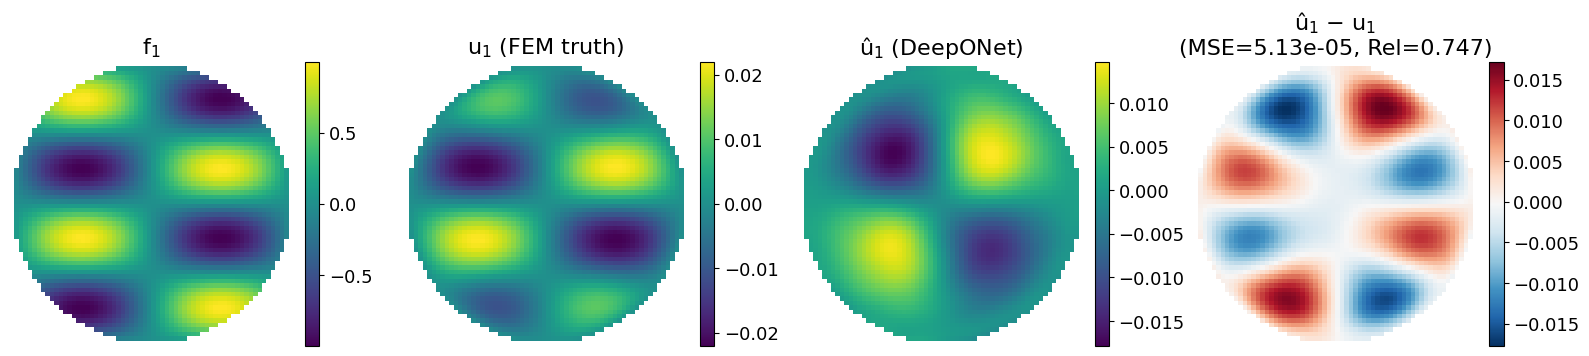

✓ Saved visualization to deeponet_sin_1_2.png
[mix                   ] MSE=7.781e-05 | RelL2=4.213e-01


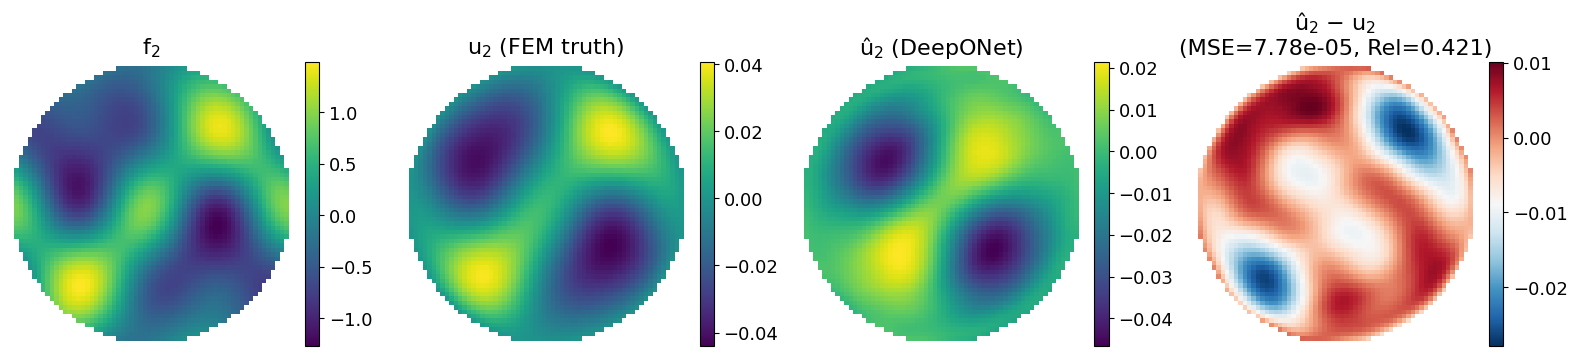

✓ Saved visualization to deeponet_mix.png
[sin_3_3               ] MSE=7.947e-06 | RelL2=1.014e+00


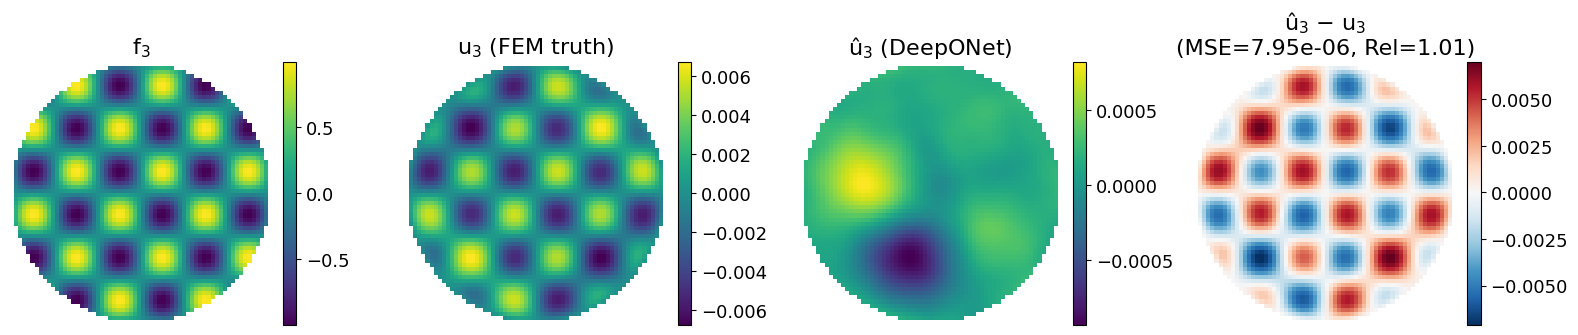

✓ Saved visualization to deeponet_sin_3_3.png
[sin_5_x               ] MSE=8.141e-06 | RelL2=1.033e+00


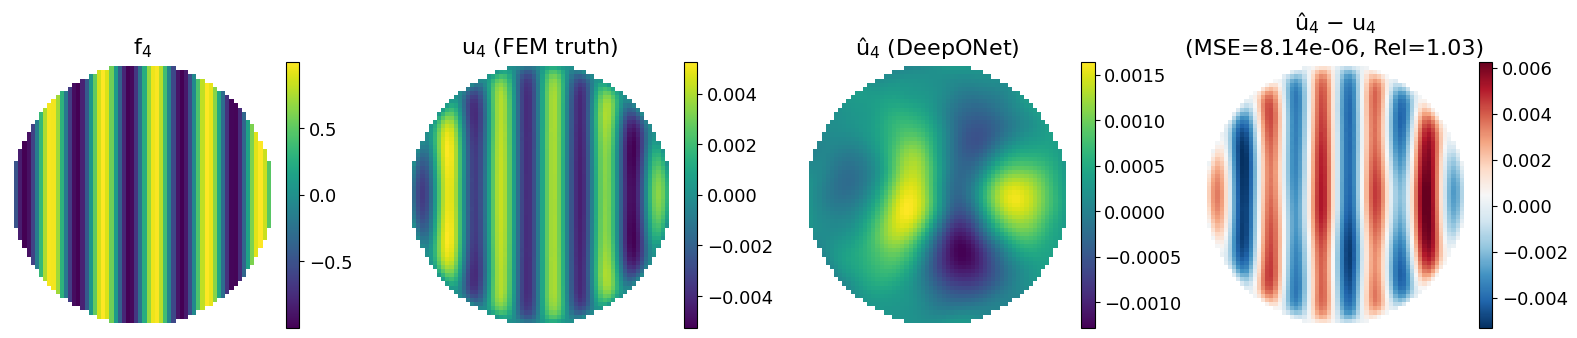

✓ Saved visualization to deeponet_sin_5_x.png
✓ Saved metrics to deeponet_customf_metrics.txt


In [ ]:
print("\n[Extra] DeepONet custom f tests (same as FNO) ...")
_ = run_custom_f_tests_deeponet(
    model=deeponet,
    grid_size=GRID_SIZE,
    radius=RADIUS,
    device=DEVICE
)